In [1]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from data.loading import load_all_months, verify_image_existence
from data.preprocessing import split_data, get_feature_columns
from utils.visualization import (
    plot_target_distribution,
    plot_correlation_matrix,
    plot_monthly_distribution,
    display_sample_images,
    plot_feature_importance_vs_target
)

DATA_DIR = project_root / "dataset" / "Solar_data"
MONTHS = ["01", "04", "07", "10"]

print(f"Project root: {project_root}")
print(f"Data directory: {DATA_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")

Project root: c:\Users\pmuzslay\suns_z3
Data directory: c:\Users\pmuzslay\suns_z3\dataset\Solar_data
Data directory exists: True


## 1. Načítanie dát

In [2]:
# Načítanie dát
df_all = load_all_months(DATA_DIR, MONTHS)

print("\nPrvých 5 riadkov:")
print(df_all.head())

print("\nInformácie o DataFrame:")
print(f"Počet riadkov: {len(df_all)}")
print(f"Počet stĺpcov: {len(df_all.columns)}")
print(f"\nStĺpce: {df_all.columns}")

Loading data from month 01...
Loading data from month 04...
Loading data from month 07...
Loading data from month 10...

Total records loaded: 6007
Months: shape: (4,)
Series: 'Month' [str]
[
	"01"
	"04"
	"07"
	"10"
]

Prvých 5 riadkov:
shape: (5, 22)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ PictureNam ┆ DateTime   ┆ Irradiance ┆ Irradianc ┆ … ┆ SunAzimut ┆ SunZenith ┆ DateTime_ ┆ Month │
         ┆ clean     ┆ ---   │-        ┆ eNotCompe ┆   ┆ h         ┆ 
│ ---        ┆ str        ┆ f64        ┆ nsated    ┆   ┆ ---       ┆ ---       ┆ ---       ┆ str   │
│ str        ┆            ┆            ┆ ---       ┆   ┆ f64       ┆ str       ┆ str       ┆       │
│            ┆            ┆            ┆ f64       ┆   ┆           ┆           ┆           ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ Alpnach_20 ┆ 01/01/2018 ┆ 3.44       ┆ 3.43      ┆ … ┆ 124.28256 ┆ 0.0

## 2. Základná štatistika

Pozrime sa na základné štatistické charakteristiky dát.

In [3]:
print("Štatistický prehľad:")
print(df_all.describe())

print("\n\nChýbajúce hodnoty:")
null_counts = df_all.null_count()
print(null_counts)

Štatistický prehľad:
shape: (9, 23)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ statistic  ┆ PictureNam ┆ DateTime   ┆ Irradianc ┆ … ┆ SunAzimut ┆ SunZenith ┆ DateTime_ ┆ Month │
         ┆ clean     ┆ ---   │-        ┆ e         ┆   ┆ h         ┆ 
│ str        ┆ ---        ┆ str        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ str   │
│            ┆ str        ┆            ┆ f64       ┆   ┆ f64       ┆ str       ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ count      ┆ 6007       ┆ 6007       ┆ 6007.0    ┆ … ┆ 6007.0    ┆ 6007      ┆ 6007      ┆ 6007  │
│ null_count ┆ 0          ┆ 0          ┆ 0.0       ┆ … ┆ 0.0       ┆ 0         ┆ 0         ┆ 0     │
│ mean       ┆ null       ┆ null       ┆ 299.04984 ┆ … ┆ 180.27601 ┆ null      ┆ null      ┆ null  │
│            ┆            ┆            ┆ 2         ┆   ┆ 5         ┆           ┆      

## 3. Analýza cieľovej premennej: Irradiance

Analyzujeme distribúciu slnečného žiarenia.

Štatistiky Irradiance:
shape: (1, 5)
┌──────┬─────────┬────────────┬────────┬────────────┐
│ min  ┆ max     ┆ mean       ┆ median ┆ std        │
│ ---  ┆ ---     ┆ ---        ┆ ---    ┆ ---        │
│ f64  ┆ f64     ┆ f64        ┆ f64    ┆ f64        │
╞══════╪═════════╪════════════╪════════╪════════════╡
│ 0.06 ┆ 1136.56 ┆ 299.049842 ┆ 198.29 ┆ 282.499805 │
└──────┴─────────┴────────────┴────────┴────────────┘


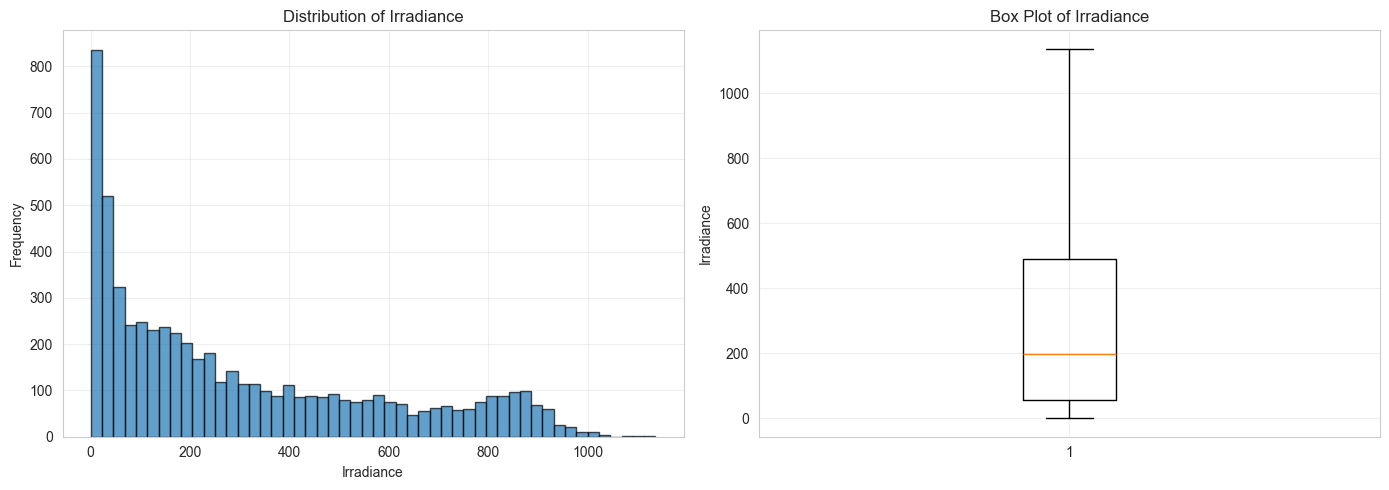

In [4]:
target_stats = df_all.select([
    pl.col("Irradiance").min().alias("min"),
    pl.col("Irradiance").max().alias("max"),
    pl.col("Irradiance").mean().alias("mean"),
    pl.col("Irradiance").median().alias("median"),
    pl.col("Irradiance").std().alias("std")
])

print("Štatistiky Irradiance:")
print(target_stats)

fig = plot_target_distribution(df_all, "Irradiance")
plt.show()

## 4. Distribúcia žiarenia podľa mesiacov

Porovnáme žiarenie v rôznych mesiacoch.

Štatistiky žiarenia po mesiacoch:
shape: (4, 6)
┌───────┬───────┬────────────┬────────────┬──────┬─────────┐
│ Month ┆ count ┆ mean       ┆ std        ┆ min  ┆ max     │
│ ---   ┆ ---   ┆ ---        ┆ ---        ┆ ---  ┆ ---     │
│ str   ┆ u32   ┆ f64        ┆ f64        ┆ f64  ┆ f64     │
╞═══════╪═══════╪════════════╪════════════╪══════╪═════════╡
│ 01    ┆ 1123  ┆ 116.281781 ┆ 115.359785 ┆ 0.06 ┆ 526.12  │
│ 04    ┆ 1621  ┆ 384.435824 ┆ 293.002644 ┆ 0.27 ┆ 1111.94 │
│ 07    ┆ 1916  ┆ 392.282187 ┆ 321.670773 ┆ 0.15 ┆ 1136.56 │
│ 10    ┆ 1347  ┆ 216.054061 ┆ 196.350735 ┆ 0.52 ┆ 962.1   │
└───────┴───────┴────────────┴────────────┴──────┴─────────┘


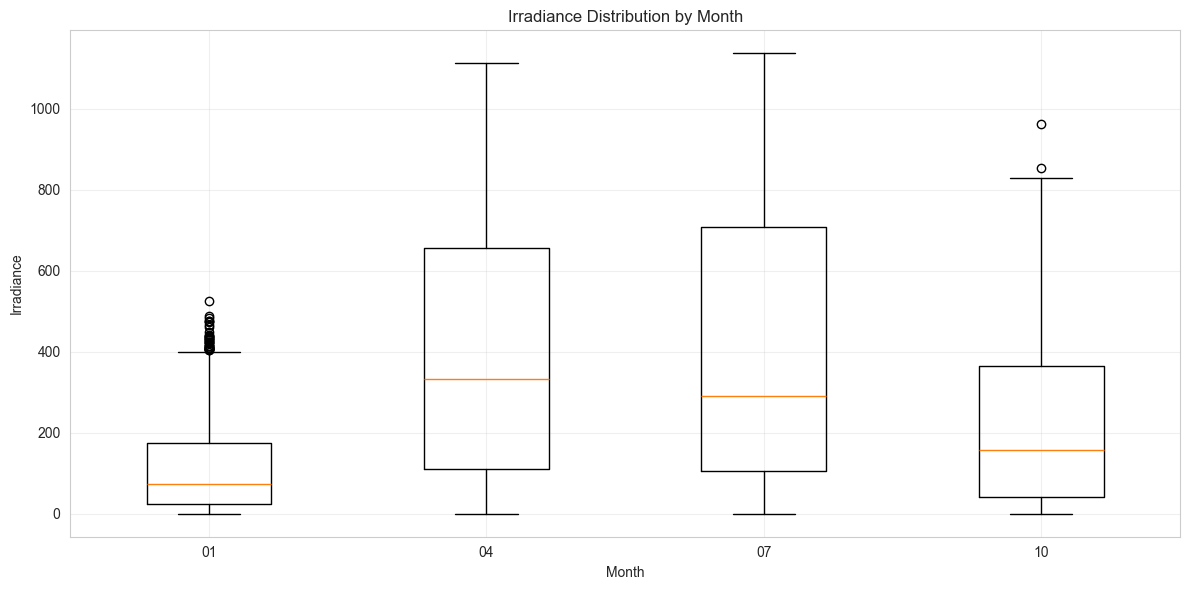

In [5]:
monthly_stats = df_all.group_by("Month").agg([
    pl.col("Irradiance").count().alias("count"),
    pl.col("Irradiance").mean().alias("mean"),
    pl.col("Irradiance").std().alias("std"),
    pl.col("Irradiance").min().alias("min"),
    pl.col("Irradiance").max().alias("max")
]).sort("Month")

print("Štatistiky žiarenia po mesiacoch:")
print(monthly_stats)

fig = plot_monthly_distribution(df_all, "Irradiance")
plt.show()

## 5. Verifikácia existencie obrázkov

Overiť, či všetky obrázky skutočne existujú v dataset.

In [6]:
df_all = verify_image_existence(df_all, DATA_DIR)

total_records = len(df_all)
existing_images = df_all.filter(pl.col("ImageExists")).shape[0]
missing_images = total_records - existing_images

print(f"Celkový počet záznamov: {total_records}")
print(f"Záznamy s existujúcimi obrázkami: {existing_images}")
print(f"Záznamy s chýbajúcimi obrázkami: {missing_images}")

if missing_images > 0:
    print("\nUpozornenie: Niektoré obrázky chýbajú!")
    missing_df = df_all.filter(~pl.col("ImageExists"))
    print("Chýbajúce obrázky po mesiacoch:")
    print(missing_df.group_by("Month").agg(pl.count().alias("missing_count")))

df_valid = df_all.filter(pl.col("ImageExists"))
print(f"\nPočet validných záznamov: {len(df_valid)}")

Celkový počet záznamov: 6007
Záznamy s existujúcimi obrázkami: 6007
Záznamy s chýbajúcimi obrázkami: 0

Počet validných záznamov: 6007


## 6. Ukážky obrázkov

Zobrazíme náhodné vzorky obrázkov s rôznymi hodnotami žiarenia.

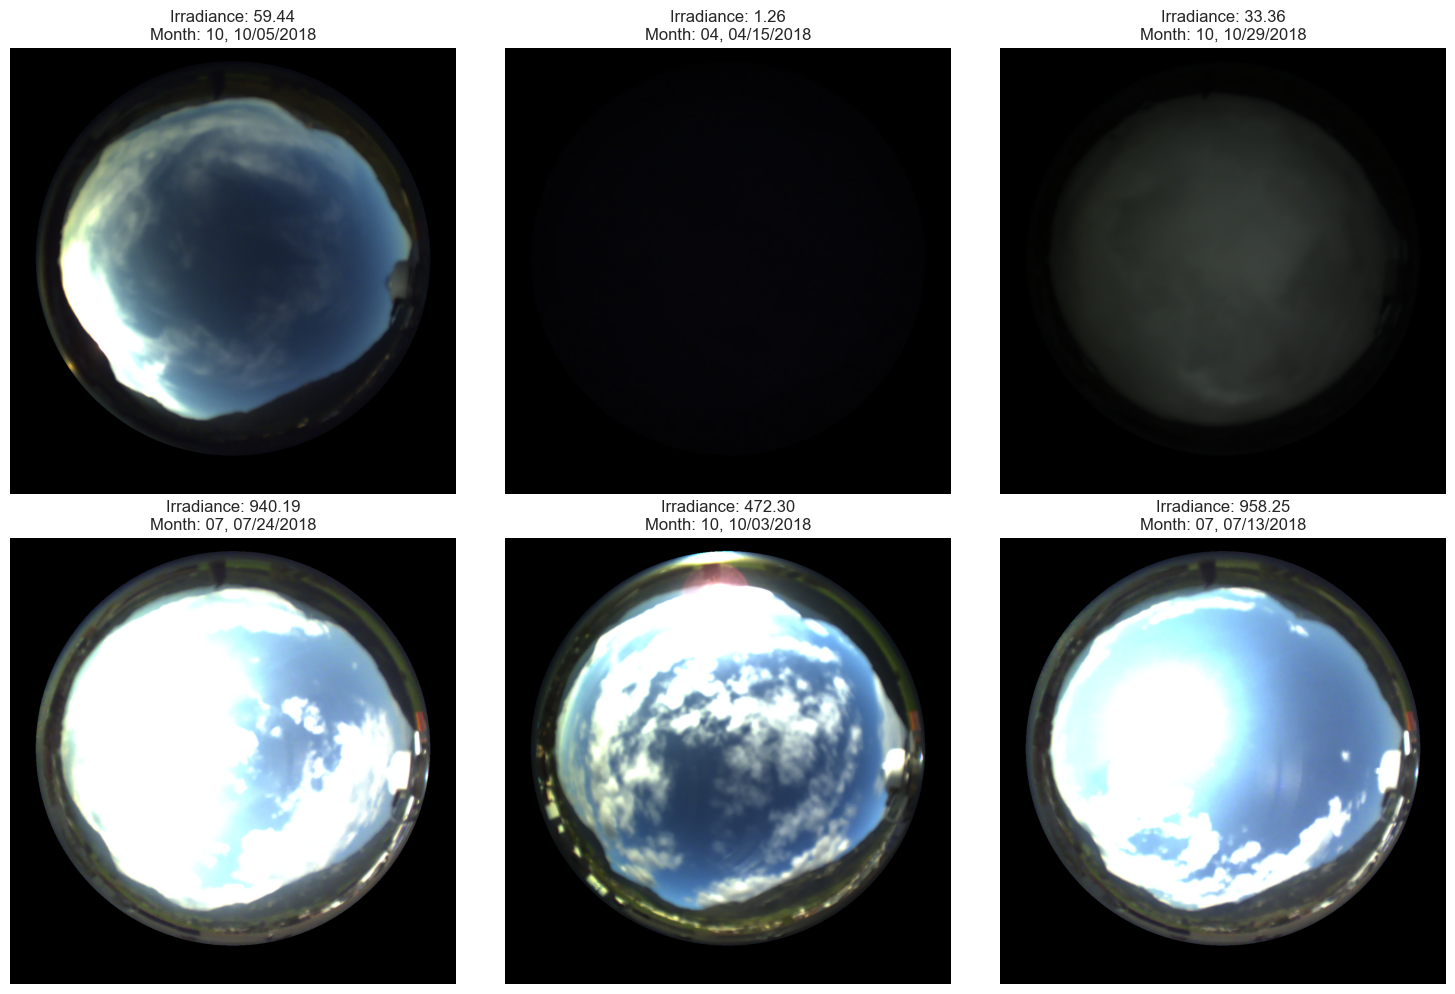


Obrázky s najnižším žiarením:


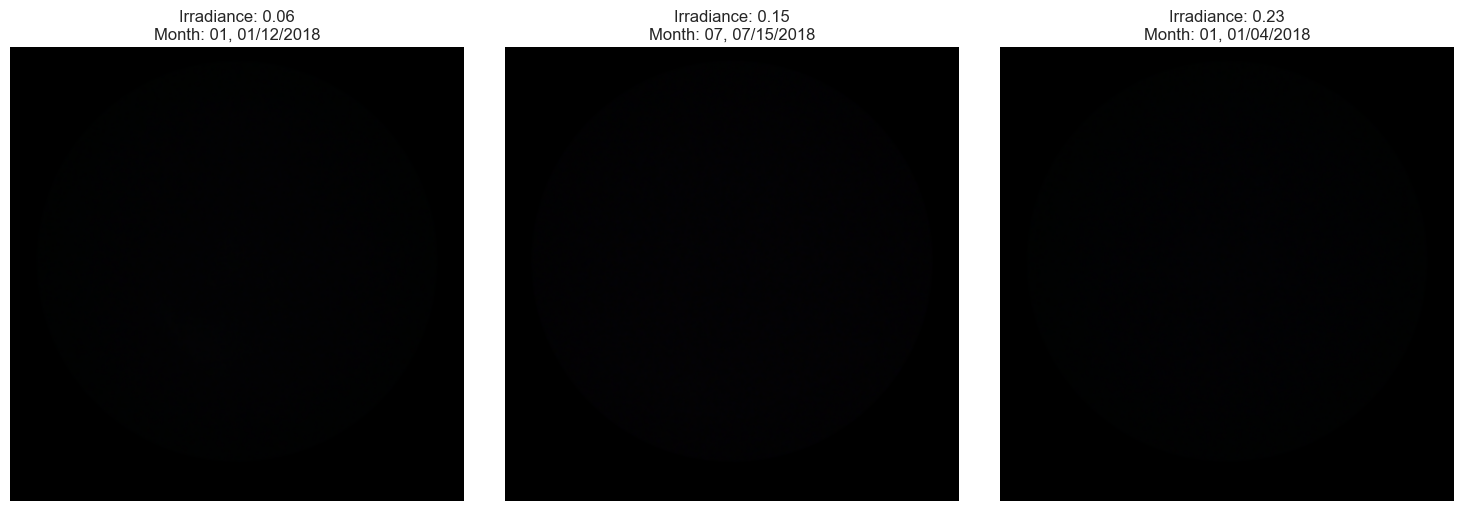


Obrázky s najvyšším žiarením:


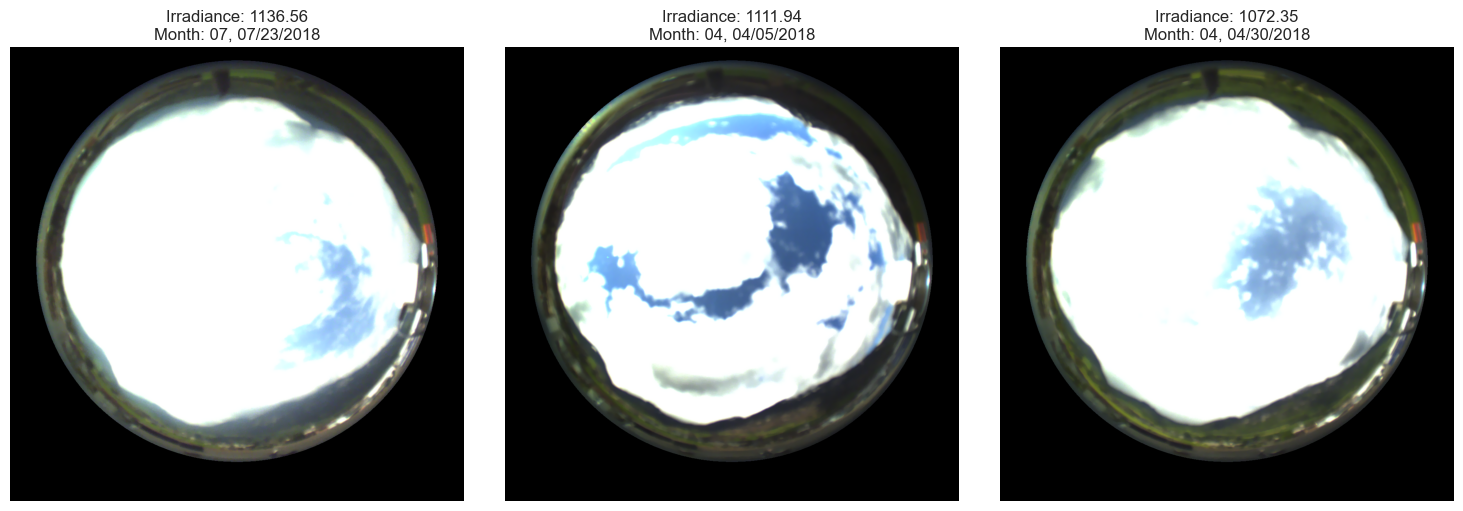

In [7]:
fig = display_sample_images(df_valid, DATA_DIR, n_samples=6, random_state=42)
plt.show()

print("\nObrázky s najnižším žiarením:")
low_irradiance = df_valid.sort("Irradiance").head(3)
fig = display_sample_images(low_irradiance, DATA_DIR, n_samples=3, random_state=None)
plt.show()

print("\nObrázky s najvyšším žiarením:")
high_irradiance = df_valid.sort("Irradiance", descending=True).head(3)
fig = display_sample_images(high_irradiance, DATA_DIR, n_samples=3, random_state=None)
plt.show()

## 7. Analýza numerických features

Analyzujeme vzťahy medzi numerickými premennými a cieľovou premennou.

Numerické features (15):
  - BodyTemperature
  - RelativeHumidity
  - HumidityTemp
  - Pressure
  - PressureAvg
  - PressureTemp
  - PressureTempAvg
  - TiltAngle
  - TiltAngleAvg
  - FanSpeed
  - HeaterCurrent
  - FanCurrent
  - SunLatitude
  - SunLongitude
  - SunAzimuth


c:\Users\pmuzslay\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pmuzslay\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


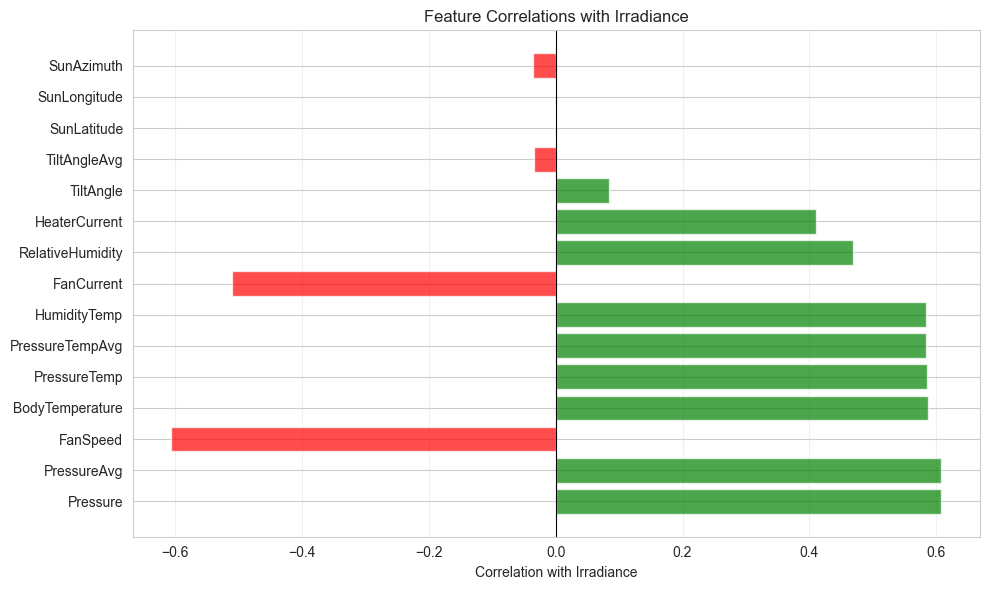

In [8]:
feature_cols = get_feature_columns(df_valid)
print(f"Numerické features ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

fig = plot_feature_importance_vs_target(df_valid, feature_cols, "Irradiance")
plt.show()

## 8. Korelačná matica

Vizualizujeme korelácie medzi všetkými numerickými premennými.

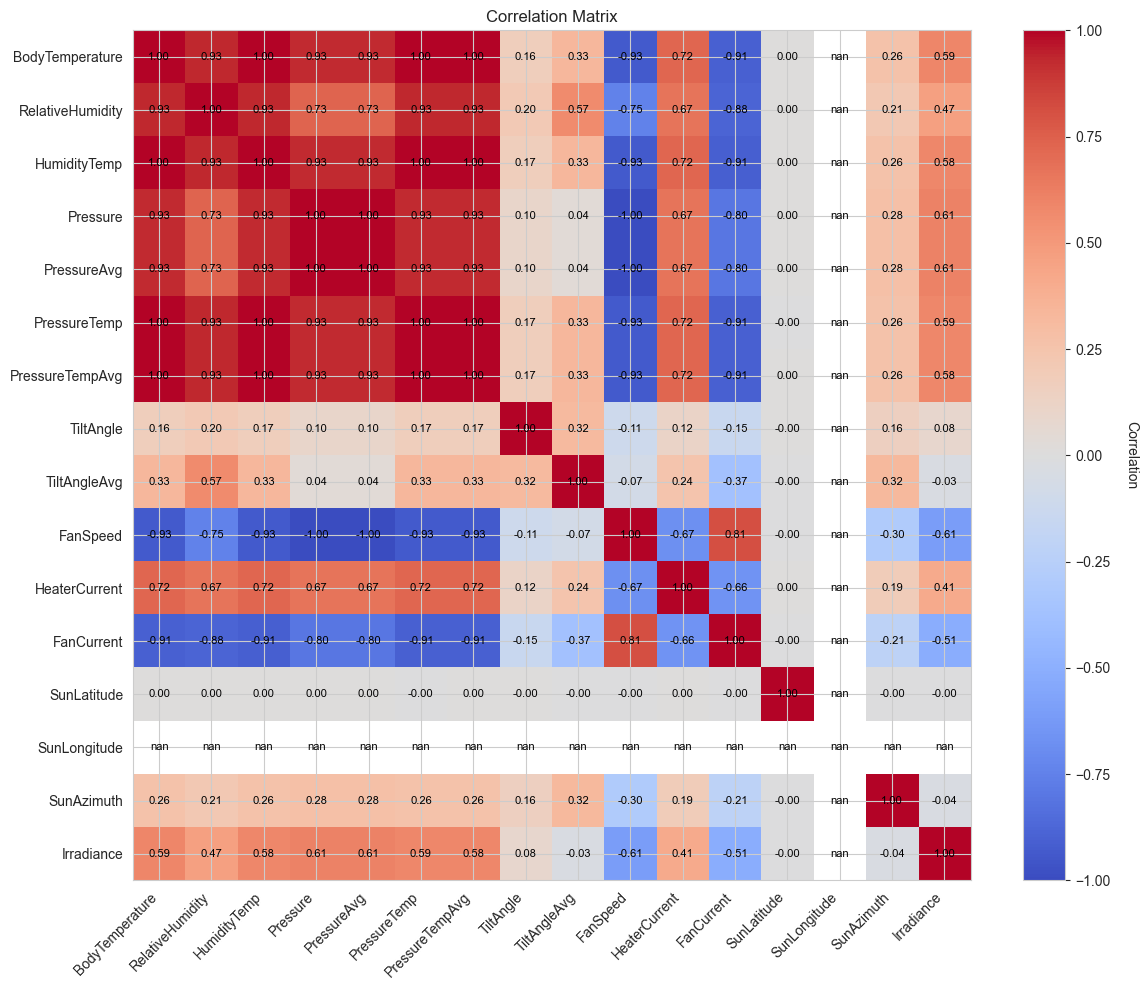

In [9]:
# Korelačná matica
fig = plot_correlation_matrix(df_valid, feature_cols, "Irradiance")
plt.show()

## 9. Detailná analýza vybraných features

Pozrime sa podrobnejšie na features s najvyššou koreláciou s cieľovou premennou.

c:\Users\pmuzslay\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pmuzslay\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top 10 korelácií s Irradiance:
  Pressure                 : +0.6085
  PressureAvg              : +0.6079
  FanSpeed                 : -0.6060
  BodyTemperature          : +0.5878
  PressureTemp             : +0.5852
  PressureTempAvg          : +0.5846
  HumidityTemp             : +0.5837
  FanCurrent               : -0.5109
  RelativeHumidity         : +0.4684
  HeaterCurrent            : +0.4105


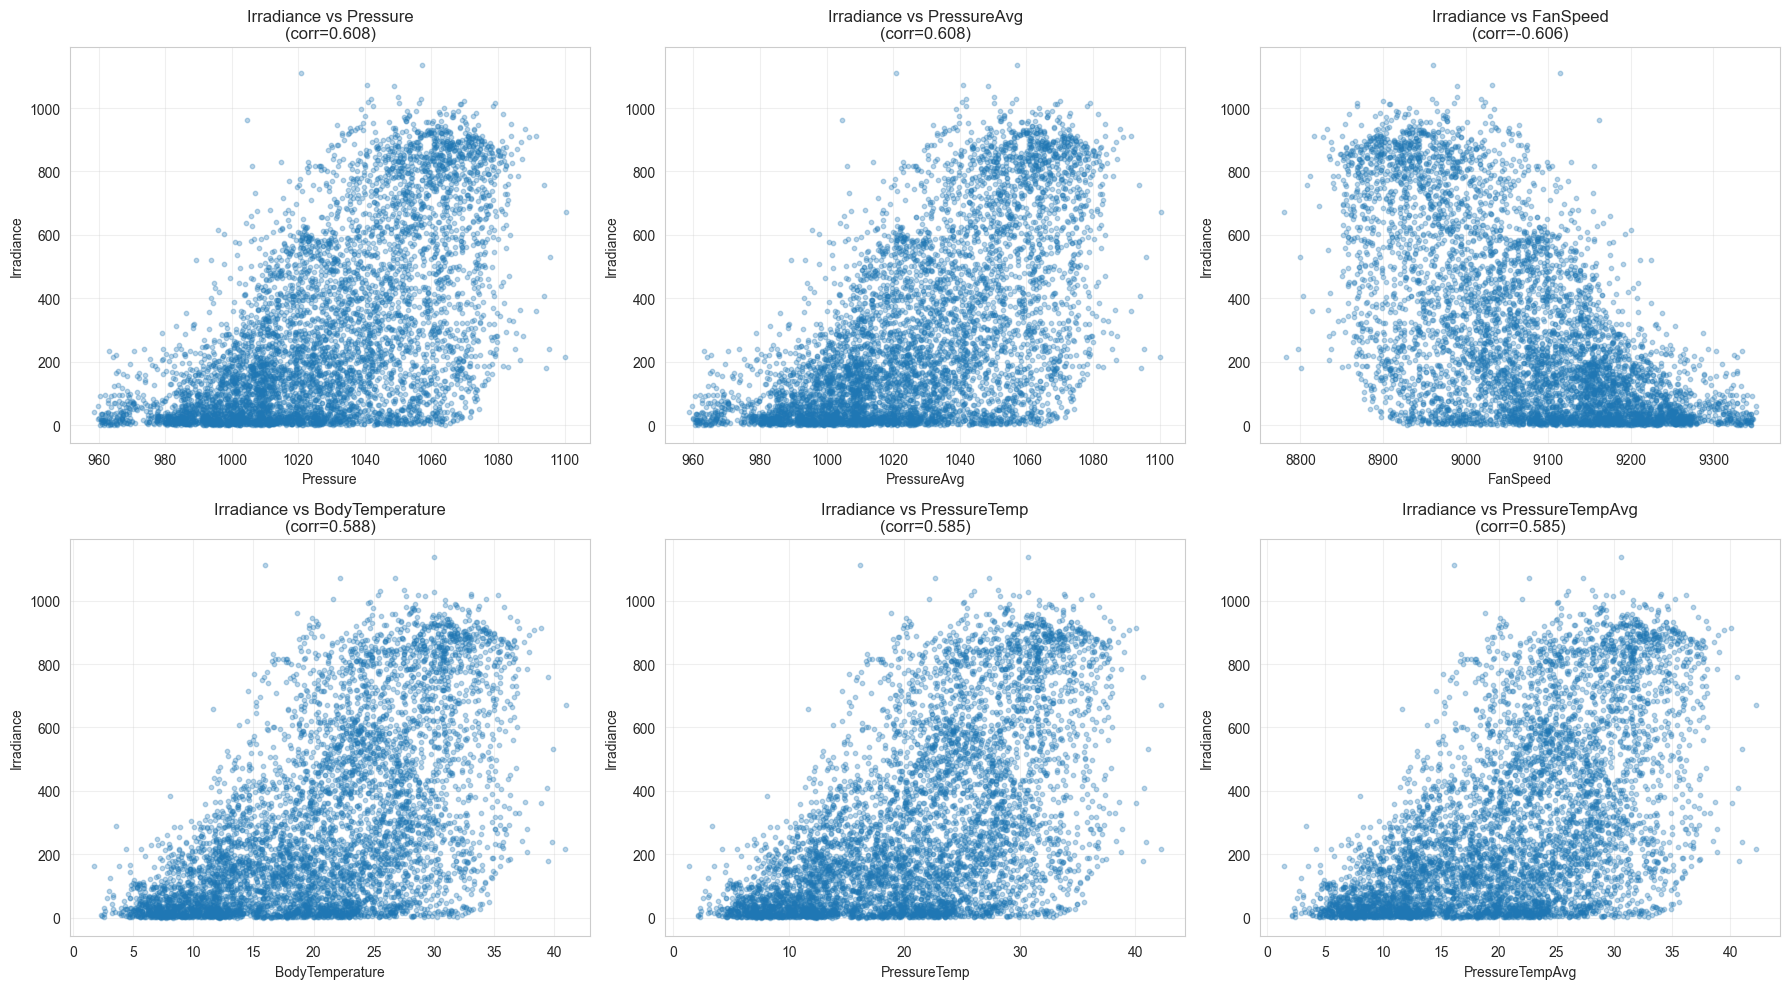

In [10]:
correlations = []
for feat in feature_cols:
    x = df_valid[feat].to_numpy()
    y = df_valid["Irradiance"].to_numpy()
    corr = np.corrcoef(x, y)[0, 1]
    correlations.append((feat, corr))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print("Top 10 korelácií s Irradiance:")
for feat, corr in correlations[:10]:
    print(f"  {feat:25s}: {corr:+.4f}")

top_features = [c[0] for c in correlations[:6]]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    ax = axes[idx]
    x = df_valid[feat].to_numpy()
    y = df_valid["Irradiance"].to_numpy()
    corr = np.corrcoef(x, y)[0, 1]
    
    ax.scatter(x, y, alpha=0.3, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel("Irradiance")
    ax.set_title(f"Irradiance vs {feat}\n(corr={corr:.3f})")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Rozdelenie dát na train/val/test

Rozdelíme dáta na trénovaciu, validačnú a testovaciu množinu (70/15/15).

In [11]:
# Rozdelenie dát
splits = split_data(
    df_valid,
    target_column="Irradiance",
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
    random_state=42
)

train_df = splits['train']
val_df = splits['val']
test_df = splits['test']

print("\nOverenie rozdelenia:")
print(f"Train: {len(train_df)} samples")
print(f"Val:   {len(val_df)} samples")
print(f"Test:  {len(test_df)} samples")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} samples")


Data split sizes:
  Train: 4204 (70.0%)
  Val:   901 (15.0%)
  Test:  902 (15.0%)

Target (Irradiance) statistics:
  train: mean=297.71, std=281.30
  val  : mean=299.44, std=286.58
  test : mean=304.90, std=284.23

Overenie rozdelenia:
Train: 4204 samples
Val:   901 samples
Test:  902 samples
Total: 6007 samples


## 11. Kontrola distribúcie po rozdelení

Overiť, či je distribúcia cieľovej premennej konzistentná naprieč split-mi.

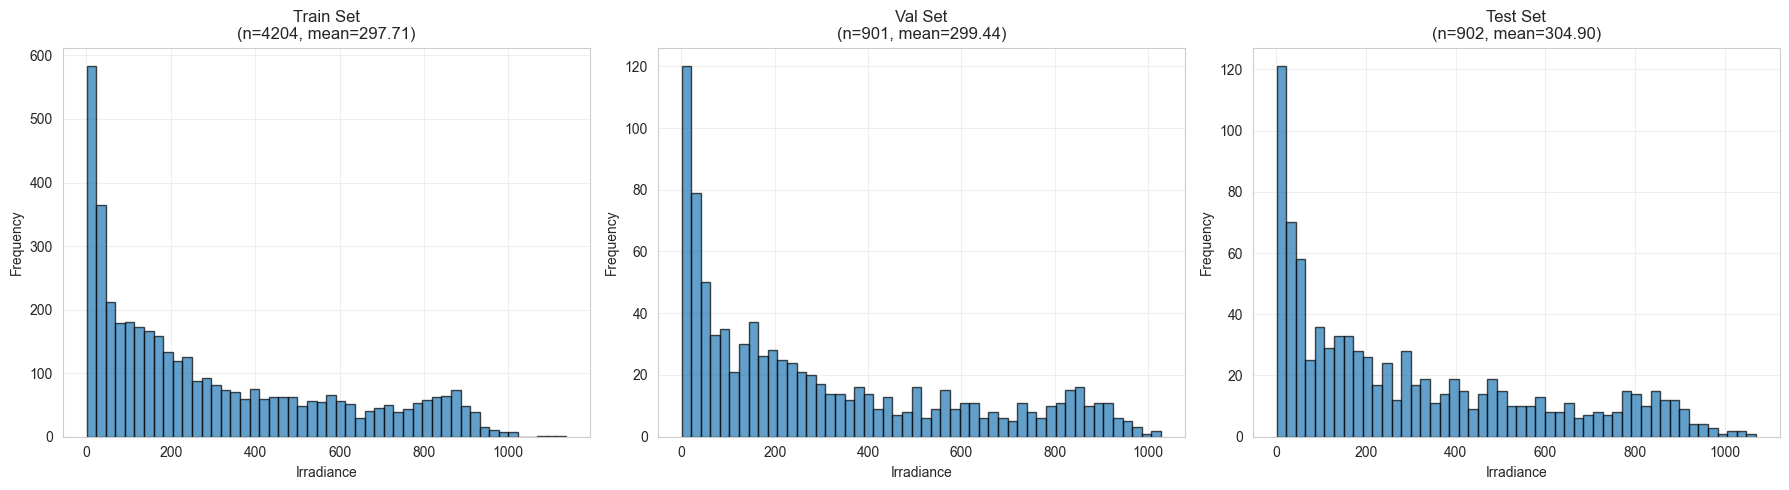


Kolmogorov-Smirnov testy (distribúcie by mali byť podobné):
Train vs Val:  statistic=0.0198, p-value=0.9271
Train vs Test: statistic=0.0286, p-value=0.5653
Val vs Test:   statistic=0.0339, p-value=0.6573


In [12]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df), 
                                                ('Val', val_df), 
                                                ('Test', test_df)]):
    values = split_df["Irradiance"].to_numpy()
    
    axes[idx].hist(values, bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel("Irradiance")
    axes[idx].set_ylabel("Frequency")
    axes[idx].set_title(f"{split_name} Set\n(n={len(split_df)}, mean={values.mean():.2f})")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ks_train_val = stats.ks_2samp(train_df["Irradiance"].to_numpy(), 
                               val_df["Irradiance"].to_numpy())
ks_train_test = stats.ks_2samp(train_df["Irradiance"].to_numpy(), 
                                test_df["Irradiance"].to_numpy())
ks_val_test = stats.ks_2samp(val_df["Irradiance"].to_numpy(), 
                              test_df["Irradiance"].to_numpy())

print("\nKolmogorov-Smirnov testy (distribúcie by mali byť podobné):")
print(f"Train vs Val:  statistic={ks_train_val.statistic:.4f}, p-value={ks_train_val.pvalue:.4f}")
print(f"Train vs Test: statistic={ks_train_test.statistic:.4f}, p-value={ks_train_test.pvalue:.4f}")
print(f"Val vs Test:   statistic={ks_val_test.statistic:.4f}, p-value={ks_val_test.pvalue:.4f}")

## 12. Uloženie rozdelených dát

Uložíme rozdelené datasety pre ďalšie použitie.

In [13]:
processed_dir = project_root / "dataset" / "processed"
processed_dir.mkdir(exist_ok=True)

train_df.write_csv(processed_dir / "train.csv")
val_df.write_csv(processed_dir / "val.csv")
test_df.write_csv(processed_dir / "test.csv")

print(f"Dáta uložené do: {processed_dir}")
print("  - train.csv")
print("  - val.csv")
print("  - test.csv")

Dáta uložené do: c:\Users\pmuzslay\suns_z3\dataset\processed
  - train.csv
  - val.csv
  - test.csv


## 13. Predzpracovanie obrázkov: Resizing

Pre zrýchlenie trénovania naresizujeme všetky obrázky na 224×224 px vopred.

In [14]:
from data.image_preprocessing import resize_and_save_images

resized_dir = project_root / "dataset" / "processed" / "resized"

print("Resizing obrázkov...")
print(f"Výstupný priečinok: {resized_dir}")

print("\nResizing train images...")
train_df_resized = resize_and_save_images(
    train_df, DATA_DIR, resized_dir / "train", image_size=(128, 128)
)

print("\nResizing val images...")
val_df_resized = resize_and_save_images(
    val_df, DATA_DIR, resized_dir / "val", image_size=(128, 128)
)

print("\nResizing test images...")
test_df_resized = resize_and_save_images(
    test_df, DATA_DIR, resized_dir / "test", image_size=(128, 128)
)
train_df_resized.write_csv(processed_dir / "train.csv")
val_df_resized.write_csv(processed_dir / "val.csv")
test_df_resized.write_csv(processed_dir / "test.csv")

print("\nVšetky obrázky naresizované a uložené!")
print(f"   Train: {len(train_df_resized)} obrázkov")
print(f"   Val:   {len(val_df_resized)} obrázkov")
print(f"   Test:  {len(test_df_resized)} obrázkov")

Resizing obrázkov...
Výstupný priečinok: c:\Users\pmuzslay\suns_z3\dataset\processed\resized

Resizing train images...


Resizing images: 100%|██████████| 4204/4204 [01:56<00:00, 36.05it/s]



Resizing val images...


Resizing images: 100%|██████████| 901/901 [00:22<00:00, 39.65it/s]



Resizing test images...


Resizing images: 100%|██████████| 902/902 [00:22<00:00, 39.25it/s]



Všetky obrázky naresizované a uložené!
   Train: 4204 obrázkov
   Val:   901 obrázkov
   Test:  902 obrázkov
